# Previsão de Consultas por Síndrome Gripal — ARS Lisboa e Vale do Tejo




## 1. Introdução

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from statsforecast import StatsForecast
from statsforecast.models import (HistoricAverage, RandomWalkWithDrift, SeasonalNaive, AutoETS, AutoARIMA, MSTL, Naive)
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mape, rmse
from statsmodels.tsa.seasonal import seasonal_decompose

C:\Users\marce\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Extração dos dados

In [2]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d %H:%M:%S')

'2026-01-20 15:50:29'

In [3]:
def extract_data_atendimentos_nos_csp_gripe(ars, start_date, end_date, cols=['no_consultas_gripe_nos_csp']):
    """
    Extracts data from the 'Atendimentos nos CSP - Gripe' dataset
    hosted at the SNS Transparency Portal.

    Parameters
    ----------
    ars : str
        Regional Health Administration (e.g., 'Norte', 'Centro', 'Lisboa e Vale do Tejo', 'Alentejo', 'Algarve')
    start_date : str (YYYY-MM-DD)
        Start date for filtering data.
    end_date : str (YYYY-MM-DD)
        End date for filtering data.
    cols : list, optional
        Columns to keep in the final DataFrame.

    Returns
    -------
    pandas.DataFrame
        A tidy DataFrame filtered by region and date range.
    """
    indicator = "atendimentos-nos-csp-gripe"
    base_url = f"https://transparencia.sns.gov.pt/api/explore/v2.1/catalog/datasets/{indicator}/records"

    limit = 100
    df_data = pd.DataFrame()

    # Split the date range into 100-day chunks to avoid server-side limits
    date_ranges = pd.date_range(start=start_date, end=end_date, freq=f"{limit}D", inclusive="left")

    for i, s_date in enumerate(date_ranges):
        s_date = s_date.strftime("%Y-%m-%d")
        e_date = (date_ranges[i + 1] - pd.Timedelta("1D")).strftime("%Y-%m-%d") if i < len(date_ranges) - 1 else end_date

        # Use requests params
        params = {
            "where": f"ars=\"ARS {ars}\" AND dia>=\"{s_date}\" AND dia<=\"{e_date}\"",
            "limit": limit
        }

        response = requests.get(base_url, params=params)
        response.raise_for_status()

        data_extract = response.json()
        df_aux = pd.json_normalize(data_extract.get("results", []))

        if not df_aux.empty:
            df_data = pd.concat([df_data, df_aux], ignore_index=True)

    # Clean and format the final DataFrame
    if not df_data.empty:
        df_data = df_data.astype(int, errors="ignore").sort_values("dia").reset_index(drop=True)
        df_data["dia"] = pd.to_datetime(df_data["dia"], errors="coerce")
        df_data = df_data.filter(["dia"] + cols)

    return df_data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3348 entries, 0 to 3347
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   dia                         3348 non-null   datetime64[ns]
 1   no_consultas_gripe_nos_csp  3348 non-null   int32         
dtypes: datetime64[ns](1), int32(1)
memory usage: 39.4 KB


None

,dia,no_consultas_gripe_nos_csp
3343,2025-12-27,100
3344,2025-12-28,101
3345,2025-12-29,657
3346,2025-12-30,486
3347,2025-12-31,142


<Axes: xlabel='dia'>

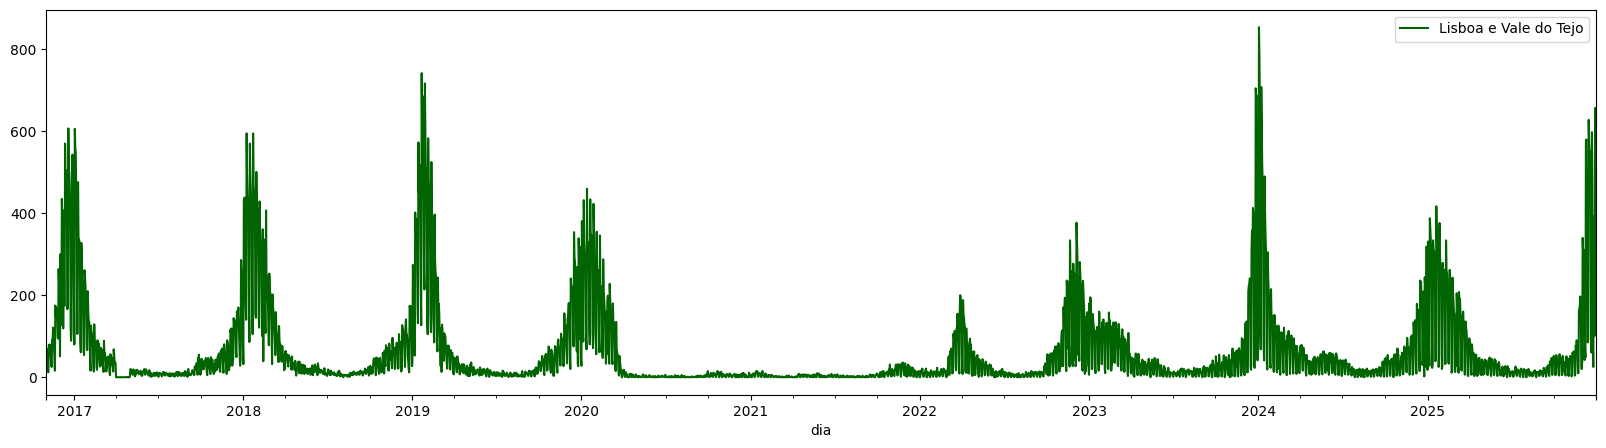

In [4]:
df_lvt = extract_data_atendimentos_nos_csp_gripe(
    ars="Lisboa e Vale do Tejo",
    start_date="2016-11-01",
    end_date="2025-12-31"
)
display(df_lvt.info())
display(df_lvt.tail())
df_lvt.plot(x="dia", y="no_consultas_gripe_nos_csp", figsize=(20,5), label="Lisboa e Vale do Tejo", color="darkgreen")

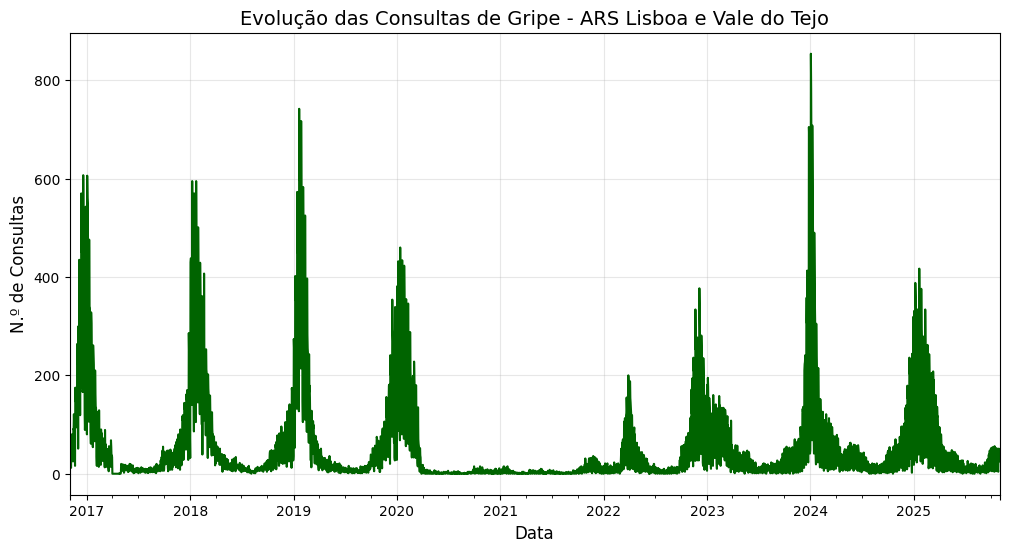

In [5]:
df_lvt = extract_data_atendimentos_nos_csp_gripe(
    ars="Lisboa e Vale do Tejo",
    start_date="2016-11-01",
    end_date="2025-10-31"
)

# Garantir que a coluna 'dia' é datetime (caso não tenha ficado na extração)
df_lvt["dia"] = pd.to_datetime(df_lvt["dia"])

# Plot ajustado com boas práticas do Módulo 1
ax = df_lvt.plot(x="dia", y="no_consultas_gripe_nos_csp", figsize=(12, 6), color="darkgreen", legend=False)
ax.set_title("Evolução das Consultas de Gripe - ARS Lisboa e Vale do Tejo", fontsize=14)
ax.set_ylabel("N.º de Consultas", fontsize=12)
ax.set_xlabel("Data", fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

In [6]:
# --- CÁLCULO DA LATÊNCIA (Investigação Obrigatória - Secção 2) ---

# 1. Identificar a data mais recente no teu dataframe principal (df_lvt)
# Estamos a usar a coluna 'dia' que vem da extração
ultima_data_disponivel = pd.to_datetime(df_lvt['dia'].max())

# 2. Definir a data de hoje (para comparar)
hoje = pd.Timestamp.now().normalize()

# 3. Calcular a diferença (o atraso em dias)
atraso = (hoje - ultima_data_disponivel).days

# 4. Apresentar os resultados para o relatório
print("-" * 40)
print("INVESTIGAÇÃO DA LATÊNCIA (Baseada no df_lvt):")
print(f"Data da execução (Hoje):      {hoje.date()}")
print(f"Último dado no df_lvt:        {ultima_data_disponivel.date()}")
print(f"LATÊNCIA OBSERVADA:           {atraso} dias de atraso")
print("-" * 40)

----------------------------------------
INVESTIGAÇÃO DA LATÊNCIA (Baseada no df_lvt):
Data da execução (Hoje):      2026-01-20
Último dado no df_lvt:        2025-10-31
LATÊNCIA OBSERVADA:           81 dias de atraso
----------------------------------------


## 3. Análise Exploratória

### 3.1 Apresentação da série

In [7]:
# Preparar o dataframe para análise (formato StatsForecast)
df_ts = df_lvt.rename(columns={
    'dia': 'ds',
    'no_consultas_gripe_nos_csp': 'y'
}).copy()

# Adicionar coluna de identificação única da série
df_ts['unique_id'] = 'LVT_Gripe'

# Apresentação da série temporal
print("="*60)
print("APRESENTAÇÃO DA SÉRIE TEMPORAL")
print("="*60)
print(f"Período: {df_ts['ds'].min().strftime('%Y-%m-%d')} a {df_ts['ds'].max().strftime('%Y-%m-%d')}")
print(f"Total de observações: {len(df_ts)}")
print(f"Frequência: Diária")
print("="*60)

# Estatísticas descritivas
print("\nEstatísticas Descritivas:")
print(df_ts['y'].describe())
print(f"\nValores em falta: {df_ts['y'].isna().sum()}")
print(f"Valores zeros: {(df_ts['y'] == 0).sum()}")

# Valores extremos
print("\n" + "="*60)
print("VALORES EXTREMOS")
print("="*60)
print("\nValores Mínimos:")
print(df_ts.nsmallest(5, 'y')[['ds', 'y']])
print("\nValores Máximos:")
print(df_ts.nlargest(5, 'y')[['ds', 'y']])


APRESENTAÇÃO DA SÉRIE TEMPORAL
Período: 2016-11-01 a 2025-10-31
Total de observações: 3287
Frequência: Diária

Estatísticas Descritivas:
count    3287.000000
mean       57.352905
std       102.265144
min         0.000000
25%         5.000000
50%        17.000000
75%        56.000000
max       854.000000
Name: y, dtype: float64

Valores em falta: 0
Valores zeros: 246

VALORES EXTREMOS

Valores Mínimos:
            ds  y
151 2017-04-01  0
152 2017-04-02  0
153 2017-04-03  0
154 2017-04-04  0
155 2017-04-05  0

Valores Máximos:
             ds    y
2619 2024-01-03  854
2620 2024-01-04  783
811  2019-01-21  742
818  2019-01-28  717
2624 2024-01-08  708


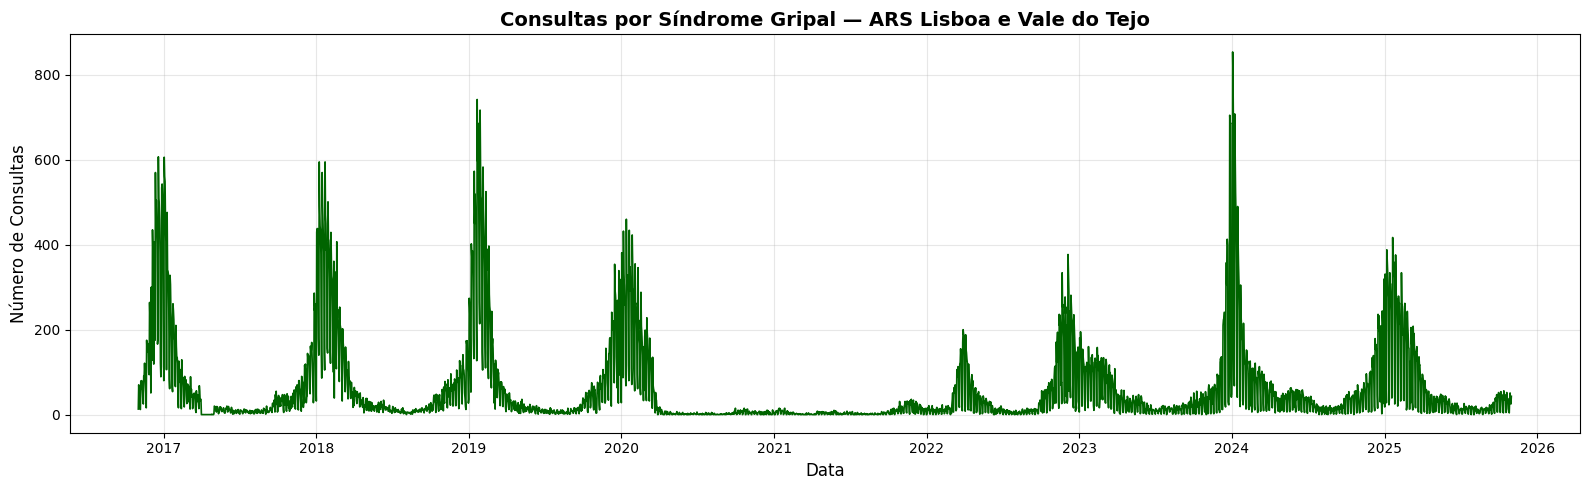

In [8]:
# Visualização da série temporal completa
plt.figure(figsize=(16, 5))
plt.plot(df_ts['ds'], df_ts['y'], linewidth=1.2, color='darkgreen')
plt.title("Consultas por Síndrome Gripal — ARS Lisboa e Vale do Tejo", fontsize=14, fontweight='bold')
plt.xlabel("Data", fontsize=12)
plt.ylabel("Número de Consultas", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3.2 Análise exploratória dos dados

#### 3.2.1 Sazonalidade Semanal

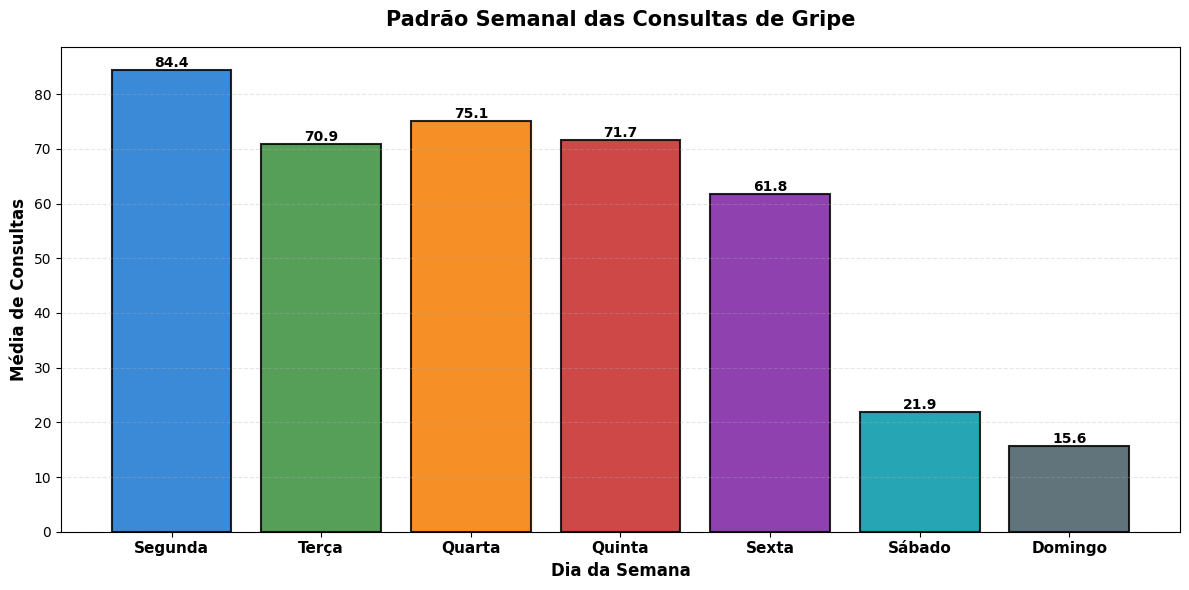

In [9]:
# Criar variável dia da semana
df_ts['weekday'] = df_ts['ds'].dt.dayofweek
df_ts['weekday_name'] = df_ts['ds'].dt.day_name()

# Média por dia da semana
weekday_mean = df_ts.groupby('weekday')['y'].mean()

# Visualização melhorada
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(7), weekday_mean.values, 
              color=['#1976D2', '#388E3C', '#F57C00', '#C62828', 
                     '#7B1FA2', '#0097A7', '#455A64'],
              edgecolor='black', linewidth=1.5, alpha=0.85)

# Labels nos dias da semana
dias_semana = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
ax.set_xticks(range(7))
ax.set_xticklabels(dias_semana, fontsize=11, fontweight='bold')

ax.set_title("Padrão Semanal das Consultas de Gripe", fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel("Média de Consultas", fontsize=12, fontweight='bold')
ax.set_xlabel("Dia da Semana", fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Adicionar valores no topo das barras
for i, (bar, value) in enumerate(zip(bars, weekday_mean.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3.2.2 Dependência temporal / autocorrelação

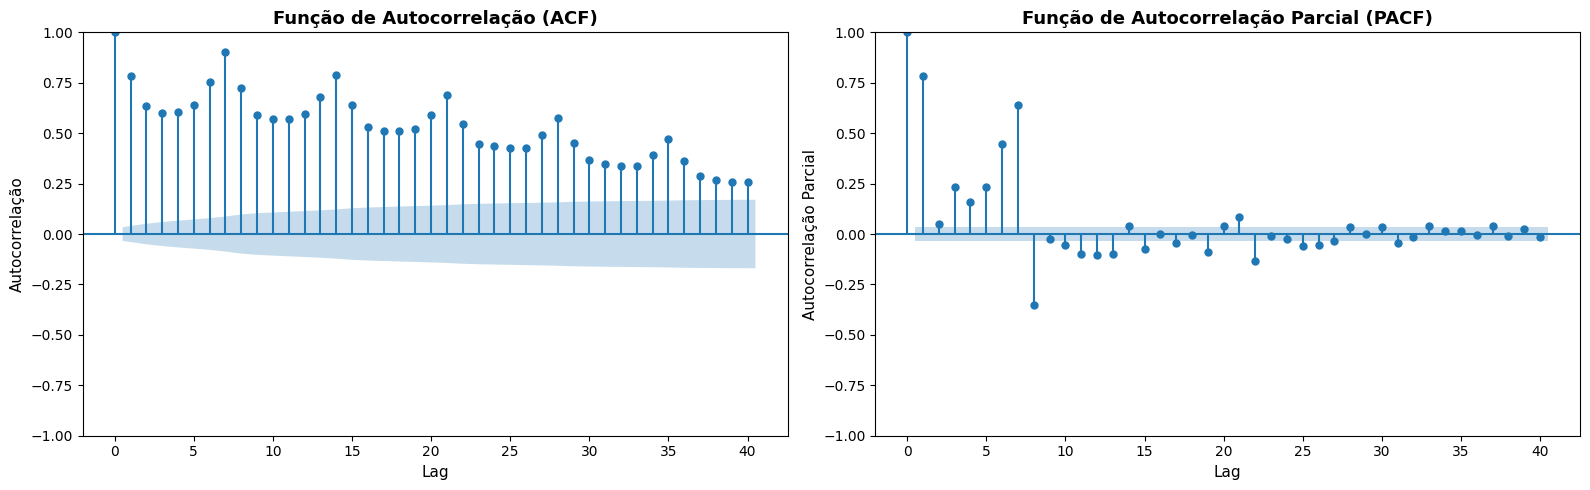

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Análise de autocorrelação e autocorrelação parcial
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF - Autocorrelation Function
plot_acf(df_ts['y'], lags=40, ax=axes[0])
axes[0].set_title("Função de Autocorrelação (ACF)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Lag", fontsize=11)
axes[0].set_ylabel("Autocorrelação", fontsize=11)

# PACF - Partial Autocorrelation Function
plot_pacf(df_ts['y'], lags=40, ax=axes[1], method='ywm')
axes[1].set_title("Função de Autocorrelação Parcial (PACF)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Lag", fontsize=11)
axes[1].set_ylabel("Autocorrelação Parcial", fontsize=11)

plt.tight_layout()
plt.show()

#### 3.2.3 Teste de Estacionariedade (ADF)

In [11]:
from statsmodels.tsa.stattools import adfuller

# Teste ADF (Augmented Dickey-Fuller)
result = adfuller(df_ts['y'].dropna())

print("="*60)
print("TESTE DE ESTACIONARIEDADE (ADF)")
print("="*60)
print(f"Estatística ADF: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Valores Críticos:")
for key, value in result[4].items():
    print(f"  {key}: {value:.4f}")

if result[1] < 0.05:
    print("\nConclusão: A série é ESTACIONÁRIA (p-value < 0.05)")
else:
    print("\nConclusão: A série é NÃO ESTACIONÁRIA (p-value >= 0.05)")

TESTE DE ESTACIONARIEDADE (ADF)
Estatística ADF: -6.3925
p-value: 0.0000
Valores Críticos:
  1%: -3.4324
  5%: -2.8624
  10%: -2.5672

Conclusão: A série é ESTACIONÁRIA (p-value < 0.05)


#### 3.2.4 Sazonalidade Anual

C:\Users\marce\AppData\Local\Temp\ipykernel_27732\3925567946.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(monthly_data, patch_artist=True,


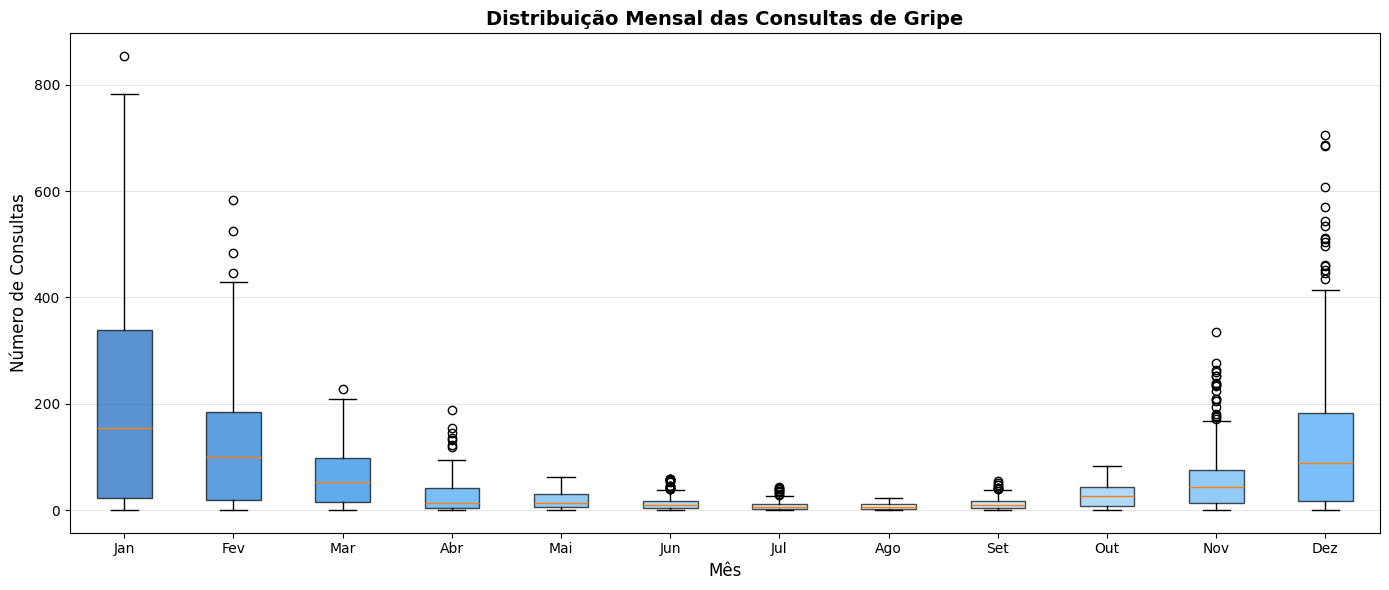


Média de consultas por mês:
mes
1     208.9
2     120.6
3      63.3
4      26.1
5      18.1
6      12.3
7       8.1
8       6.2
9      11.8
10     27.1
11     57.8
12    129.7
Name: y, dtype: float64


In [12]:
# Adicionar coluna de mês
df_ts['mes'] = df_ts['ds'].dt.month

# Boxplot por mês
fig, ax = plt.subplots(figsize=(14, 6))
monthly_data = [df_ts[df_ts['mes'] == m]['y'].values for m in range(1, 13)]
bp = ax.boxplot(monthly_data, patch_artist=True, 
                labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                       'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# Colorir as caixas
colors = ['#1565C0', '#1976D2', '#1E88E5', '#42A5F5', '#64B5F6', '#90CAF9',
          '#BBDEFB', '#E3F2FD', '#BBDEFB', '#90CAF9', '#64B5F6', '#42A5F5']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Distribuição Mensal das Consultas de Gripe", fontsize=14, fontweight='bold')
ax.set_xlabel("Mês", fontsize=12)
ax.set_ylabel("Número de Consultas", fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Estatísticas por mês
print("\nMédia de consultas por mês:")
print(df_ts.groupby('mes')['y'].mean().round(1))

#### 3.2.5 Análise de Tendência (Médias Móveis)

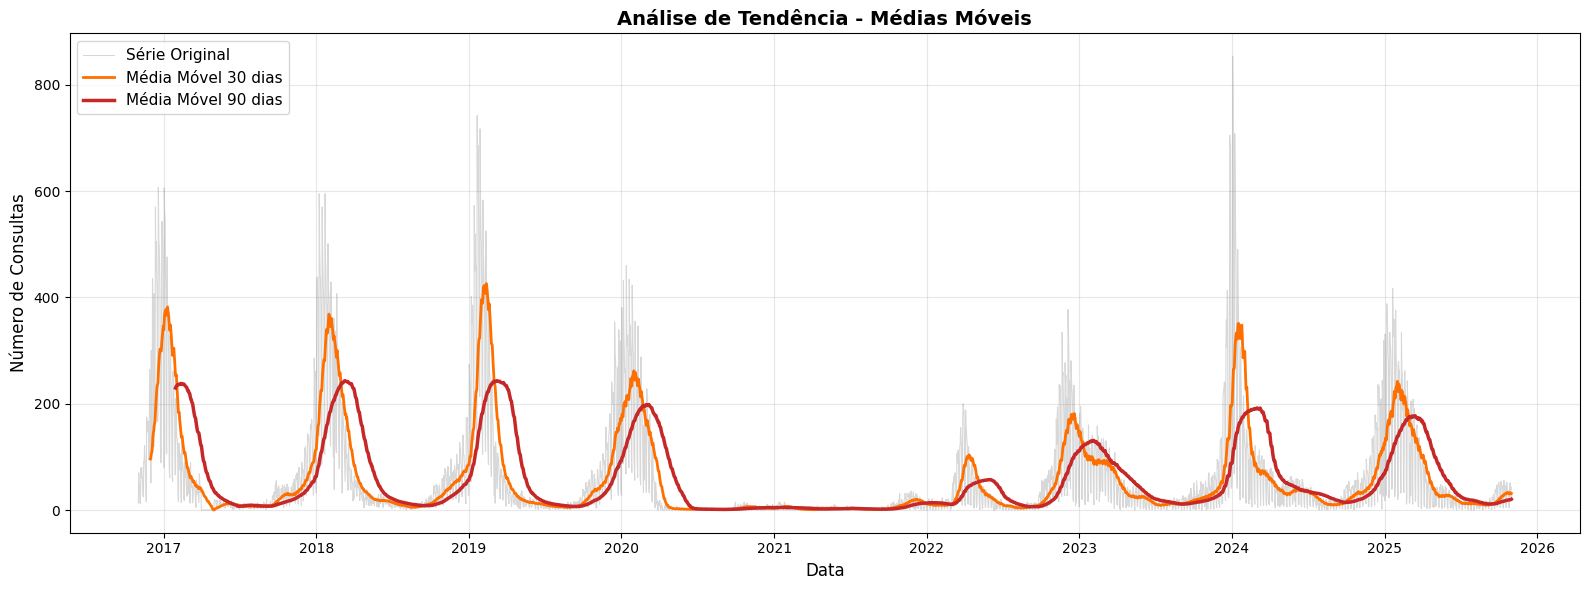


ANÁLISE DO PERÍODO RECENTE (2024-09-01 a 2025-10-31)
Total de observações: 426
Média: 62.03
Desvio padrão: 86.03
Mínimo: 0
Máximo: 417


In [13]:
# Calcular médias móveis para visualizar tendência
ma_30 = df_ts['y'].rolling(window=30).mean()
ma_90 = df_ts['y'].rolling(window=90).mean()

# Visualização
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_ts['ds'], df_ts['y'], alpha=0.3, color='gray', linewidth=0.8, label='Série Original')
ax.plot(df_ts['ds'], ma_30, color='#FF6F00', linewidth=2, label='Média Móvel 30 dias')
ax.plot(df_ts['ds'], ma_90, color='#C62828', linewidth=2.5, label='Média Móvel 90 dias')

ax.set_title("Análise de Tendência - Médias Móveis", fontsize=14, fontweight='bold')
ax.set_xlabel("Data", fontsize=12)
ax.set_ylabel("Número de Consultas", fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Foco no período mais recente (2024-09-01 a 2025-10-31)
df_recent = df_ts[(df_ts['ds'] >= '2024-09-01') & (df_ts['ds'] <= '2025-10-31')].copy()

print("\n" + "="*60)
print("ANÁLISE DO PERÍODO RECENTE (2024-09-01 a 2025-10-31)")
print("="*60)
print(f"Total de observações: {len(df_recent)}")
print(f"Média: {df_recent['y'].mean():.2f}")
print(f"Desvio padrão: {df_recent['y'].std():.2f}")
print(f"Mínimo: {df_recent['y'].min()}")
print(f"Máximo: {df_recent['y'].max()}")
print("="*60)

#### 3.2.6 Detecção de Outliers (método IQR)

DETECÇÃO DE OUTLIERS (Método IQR)
Q1 (25%): 5.00
Q3 (75%): 56.00
IQR: 51.00
Limite inferior: -71.50
Limite superior: 132.50

Número de outliers: 411 (12.50% dos dados)


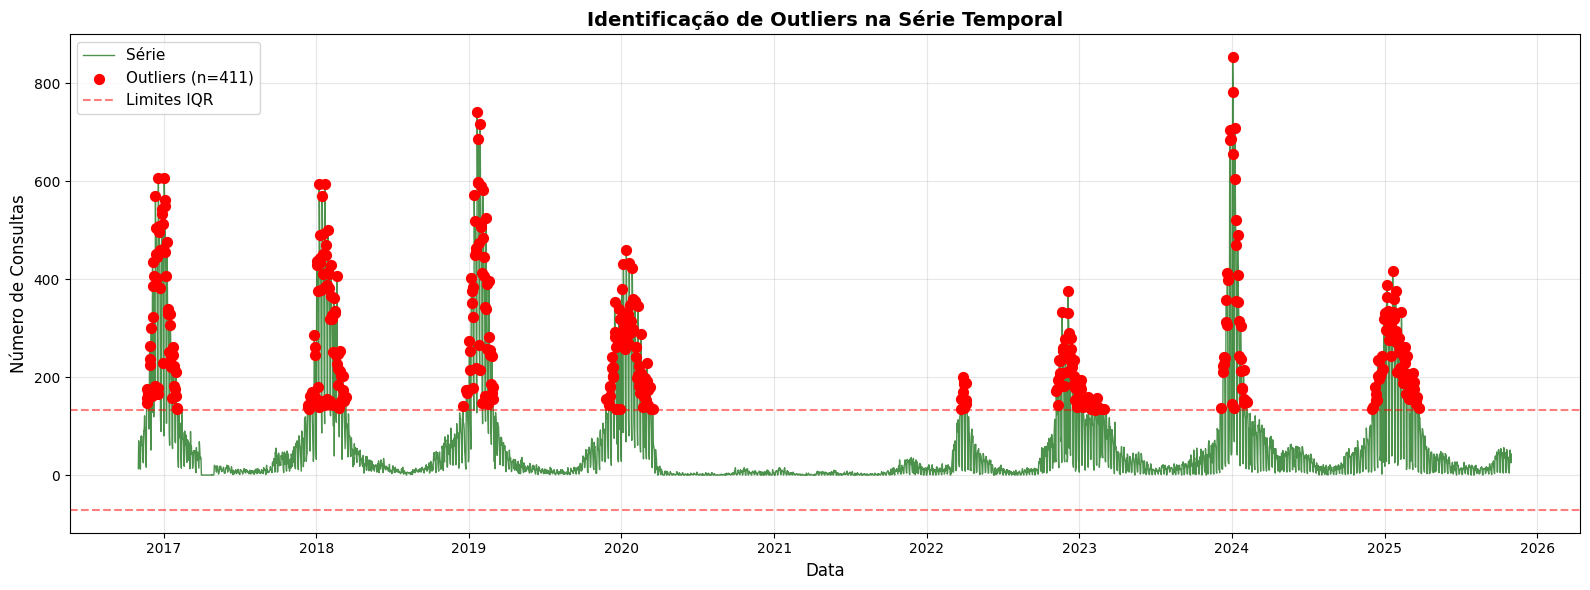


Exemplos de outliers (valores mais extremos):
             ds    y
2619 2024-01-03  854
2620 2024-01-04  783
811  2019-01-21  742
818  2019-01-28  717
2624 2024-01-08  708
2612 2023-12-27  705
2614 2023-12-29  687
813  2019-01-23  686
2613 2023-12-28  684
2621 2024-01-05  655


In [14]:
# Identificar outliers usando o método IQR (Interquartile Range)
Q1 = df_ts['y'].quantile(0.25)
Q3 = df_ts['y'].quantile(0.75)
IQR = Q3 - Q1

# Limites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers = df_ts[(df_ts['y'] < lower_bound) | (df_ts['y'] > upper_bound)]

print("="*60)
print("DETECÇÃO DE OUTLIERS (Método IQR)")
print("="*60)
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite inferior: {lower_bound:.2f}")
print(f"Limite superior: {upper_bound:.2f}")
print(f"\nNúmero de outliers: {len(outliers)} ({len(outliers)/len(df_ts)*100:.2f}% dos dados)")
print("="*60)

# Visualização com outliers destacados
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_ts['ds'], df_ts['y'], color='darkgreen', linewidth=1, alpha=0.7, label='Série')
ax.scatter(outliers['ds'], outliers['y'], color='red', s=50, zorder=5, label=f'Outliers (n={len(outliers)})')
ax.axhline(y=upper_bound, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='Limites IQR')
ax.axhline(y=lower_bound, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

ax.set_title("Identificação de Outliers na Série Temporal", fontsize=14, fontweight='bold')
ax.set_xlabel("Data", fontsize=12)
ax.set_ylabel("Número de Consultas", fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar alguns outliers
if len(outliers) > 0:
    print("\nExemplos de outliers (valores mais extremos):")
    print(outliers.nlargest(10, 'y')[['ds', 'y']])

#### 3.2.7 Análise de Missing Values e Zeros

ANÁLISE DE VALORES EM FALTA E ZEROS
Total de observações: 3287
Missing values: 0 (0.00%)
Valores zero: 246 (7.48%)

Distribuição de zeros por dia da semana:
Seg: 12
Ter: 11
Qua: 13
Qui: 18
Sex: 26
Sáb: 81
Dom: 85


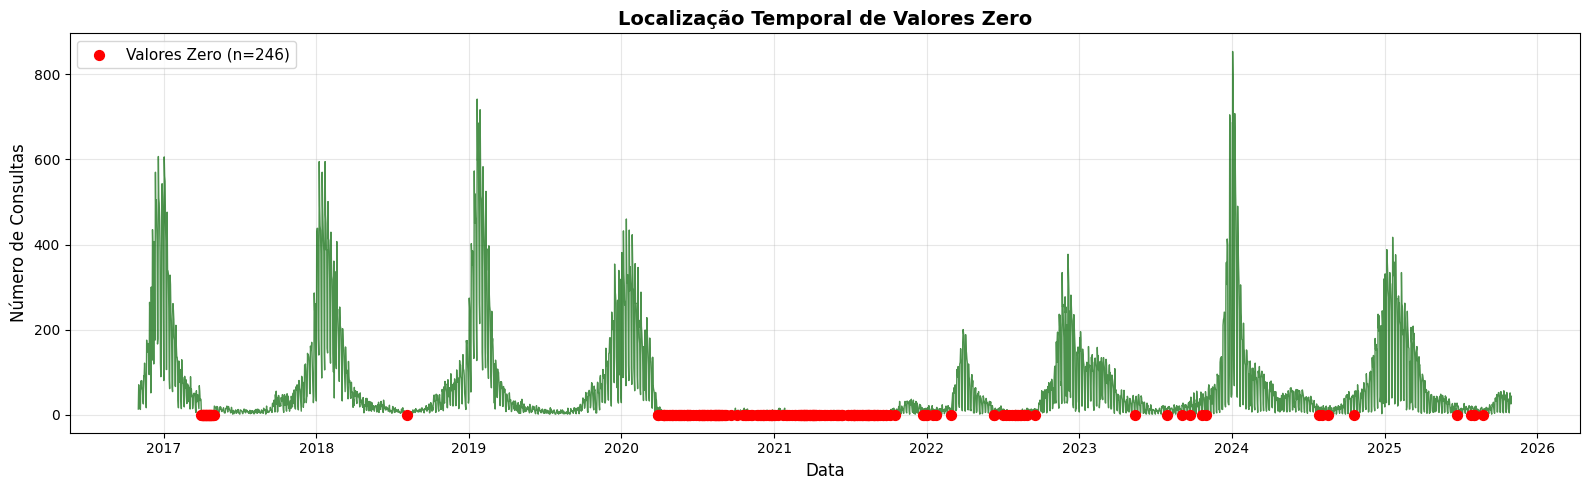


✓ Não existem valores em falta na série.


In [15]:
# Análise de missing values
missing_count = df_ts['y'].isna().sum()
zero_count = (df_ts['y'] == 0).sum()

print("="*60)
print("ANÁLISE DE VALORES EM FALTA E ZEROS")
print("="*60)
print(f"Total de observações: {len(df_ts)}")
print(f"Missing values: {missing_count} ({missing_count/len(df_ts)*100:.2f}%)")
print(f"Valores zero: {zero_count} ({zero_count/len(df_ts)*100:.2f}%)")
print("="*60)

# Análise temporal de zeros (se existirem)
if zero_count > 0:
    zeros_df = df_ts[df_ts['y'] == 0].copy()
    zeros_df['weekday'] = zeros_df['ds'].dt.dayofweek
    
    print("\nDistribuição de zeros por dia da semana:")
    dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
    for i in range(7):
        count = (zeros_df['weekday'] == i).sum()
        print(f"{dias[i]}: {count}")
    
    # Visualização dos zeros ao longo do tempo
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(df_ts['ds'], df_ts['y'], color='darkgreen', linewidth=1, alpha=0.7)
    ax.scatter(zeros_df['ds'], zeros_df['y'], color='red', s=50, zorder=5, 
               label=f'Valores Zero (n={zero_count})')
    
    ax.set_title("Localização Temporal de Valores Zero", fontsize=14, fontweight='bold')
    ax.set_xlabel("Data", fontsize=12)
    ax.set_ylabel("Número de Consultas", fontsize=12)
    ax.legend(loc='upper left', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ Não existem valores zero na série.")

if missing_count == 0:
    print("\n✓ Não existem valores em falta na série.")

> Agora para o período específico de 2024-09-01 a 2025-10-31

Sazonalidade Semanal

PERÍODO DE ANÁLISE: 2024-09-01 a 2025-10-31
Total de observações: 426
Início: 2024-09-01
Fim: 2025-10-31


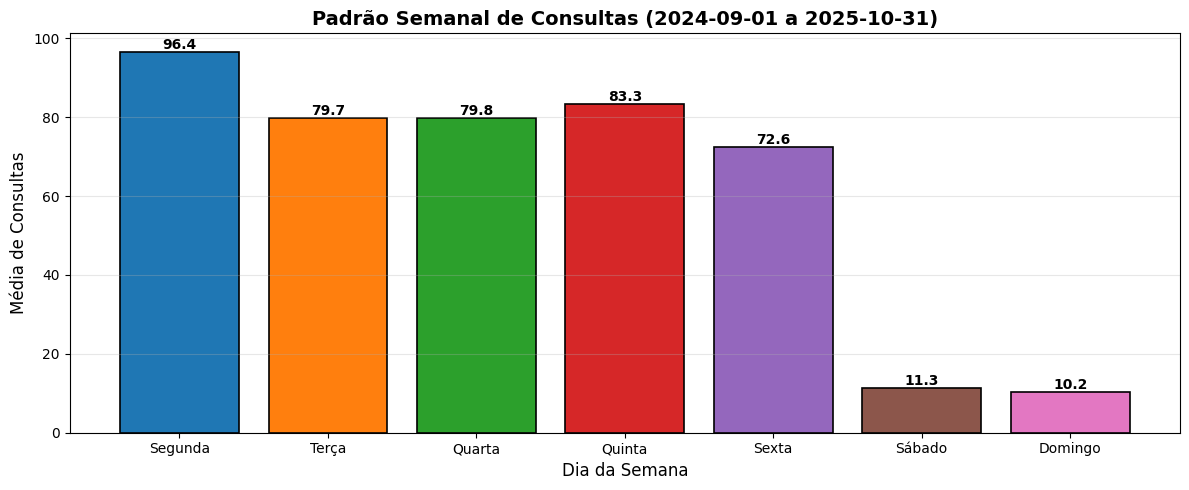


Estatísticas por dia da semana:
      nome       mean  count
0  Segunda  96.442623     61
1    Terça  79.704918     61
2   Quarta  79.786885     61
3   Quinta  83.344262     61
4    Sexta  72.557377     61
5   Sábado  11.300000     60
6  Domingo  10.245902     61

 Interpretação:
O padrão sazonal semanal mantém-se consistente no período recente de análise,
confirmando a robustez do efeito sazonal identificado nos dados históricos completos.


In [16]:
# Filtrar dados para o período específico
df_periodo = df_ts[
    (df_ts['ds'] >= '2024-09-01') & 
    (df_ts['ds'] <= '2025-10-31')
].copy()

print("="*60)
print("PERÍODO DE ANÁLISE: 2024-09-01 a 2025-10-31")
print("="*60)
print(f"Total de observações: {len(df_periodo)}")
print(f"Início: {df_periodo['ds'].min().strftime('%Y-%m-%d')}")
print(f"Fim: {df_periodo['ds'].max().strftime('%Y-%m-%d')}")
print("="*60)

# Análise de sazonalidade semanal no período específico
df_periodo['dia_semana'] = df_periodo['ds'].dt.dayofweek
weekday_stats = df_periodo.groupby('dia_semana')['y'].agg(['mean', 'count']).reset_index()

dias_nomes = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
weekday_stats['nome'] = [dias_nomes[i] for i in weekday_stats['dia_semana']]

# Visualização
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(weekday_stats['nome'], weekday_stats['mean'], 
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2'],
              edgecolor='black', linewidth=1.2)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("Padrão Semanal de Consultas (2024-09-01 a 2025-10-31)", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("Dia da Semana", fontsize=12)
ax.set_ylabel("Média de Consultas", fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEstatísticas por dia da semana:")
print(weekday_stats[['nome', 'mean', 'count']])

print("\n Interpretação:")
print("O padrão sazonal semanal mantém-se consistente no período recente de análise,")
print("confirmando a robustez do efeito sazonal identificado nos dados históricos completos.")

 Função de Autocorrelação (ACF) e Autocorrelação Parcial (PACF)

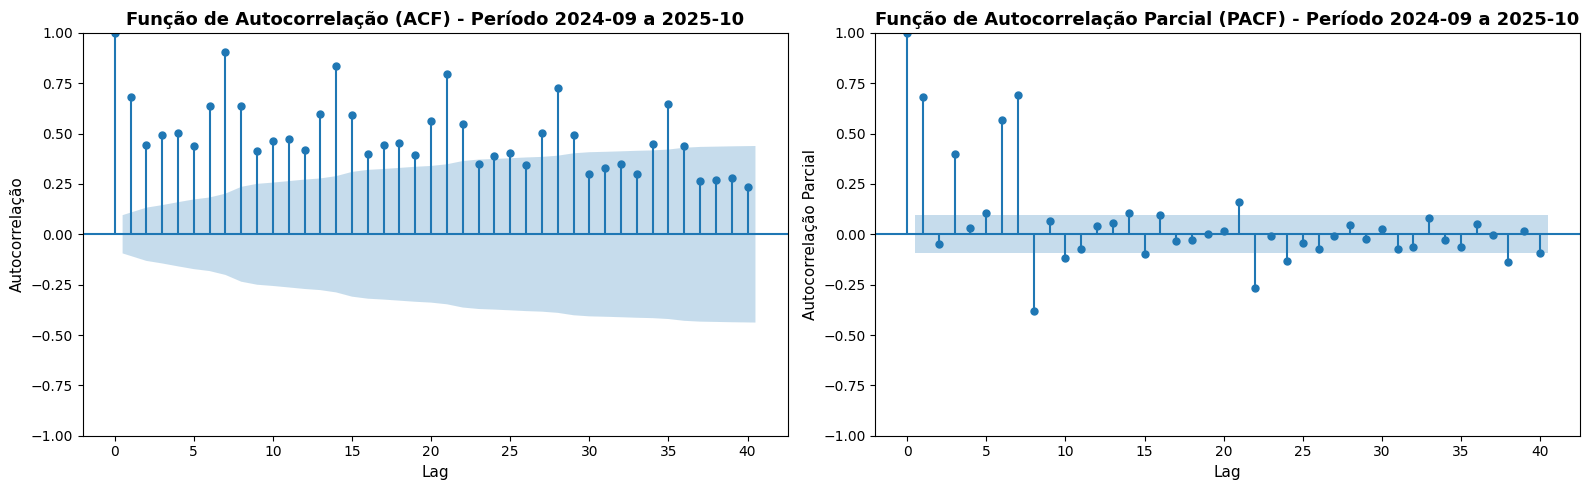

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Gráficos de ACF e PACF para o período específico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF
plot_acf(df_periodo['y'], lags=40, ax=axes[0])
axes[0].set_title("Função de Autocorrelação (ACF) - Período 2024-09 a 2025-10", 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel("Lag", fontsize=11)
axes[0].set_ylabel("Autocorrelação", fontsize=11)

# PACF
plot_pacf(df_periodo['y'], lags=40, ax=axes[1], method='ywm')
axes[1].set_title("Função de Autocorrelação Parcial (PACF) - Período 2024-09 a 2025-10", 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel("Lag", fontsize=11)
axes[1].set_ylabel("Autocorrelação Parcial", fontsize=11)

plt.tight_layout()
plt.show()

 Teste de Estacionariedade (ADF)

In [18]:
from statsmodels.tsa.stattools import adfuller

# Teste ADF (Augmented Dickey-Fuller) para o período específico
result = adfuller(df_periodo['y'].dropna())

print("="*60)
print("TESTE DE ESTACIONARIEDADE (ADF)")
print("Período: 2024-09-01 a 2025-10-31")
print("="*60)
print(f"Estatística ADF: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Valores Críticos:")
for key, value in result[4].items():
    print(f"  {key}: {value:.4f}")

if result[1] < 0.05:
    print("\nConclusão: A série é ESTACIONÁRIA (p-value < 0.05)")
else:
    print("\nConclusão: A série é NÃO-ESTACIONÁRIA (p-value >= 0.05)")
print("="*60)

TESTE DE ESTACIONARIEDADE (ADF)
Período: 2024-09-01 a 2025-10-31
Estatística ADF: -1.2297
p-value: 0.6607
Valores Críticos:
  1%: -3.4464
  5%: -2.8686
  10%: -2.5705

Conclusão: A série é NÃO-ESTACIONÁRIA (p-value >= 0.05)


### 3.3 Decomposição da Série Temporal (STL)

In [19]:
# Selecionar apenas o período exigido para a decomposição
df_decomp = df_ts[
    (df_ts['ds'] >= '2024-09-01') &
    (df_ts['ds'] <= '2025-10-31')
].copy()

df_decomp.head(), df_decomp.tail()


(             ds   y  unique_id  weekday weekday_name  mes
 2861 2024-09-01   1  LVT_Gripe        6       Sunday    9
 2862 2024-09-02  17  LVT_Gripe        0       Monday    9
 2863 2024-09-03   9  LVT_Gripe        1      Tuesday    9
 2864 2024-09-04  15  LVT_Gripe        2    Wednesday    9
 2865 2024-09-05  18  LVT_Gripe        3     Thursday    9,
              ds   y  unique_id  weekday weekday_name  mes
 3282 2025-10-27  38  LVT_Gripe        0       Monday   10
 3283 2025-10-28  51  LVT_Gripe        1      Tuesday   10
 3284 2025-10-29  34  LVT_Gripe        2    Wednesday   10
 3285 2025-10-30  25  LVT_Gripe        3     Thursday   10
 3286 2025-10-31  43  LVT_Gripe        4       Friday   10)

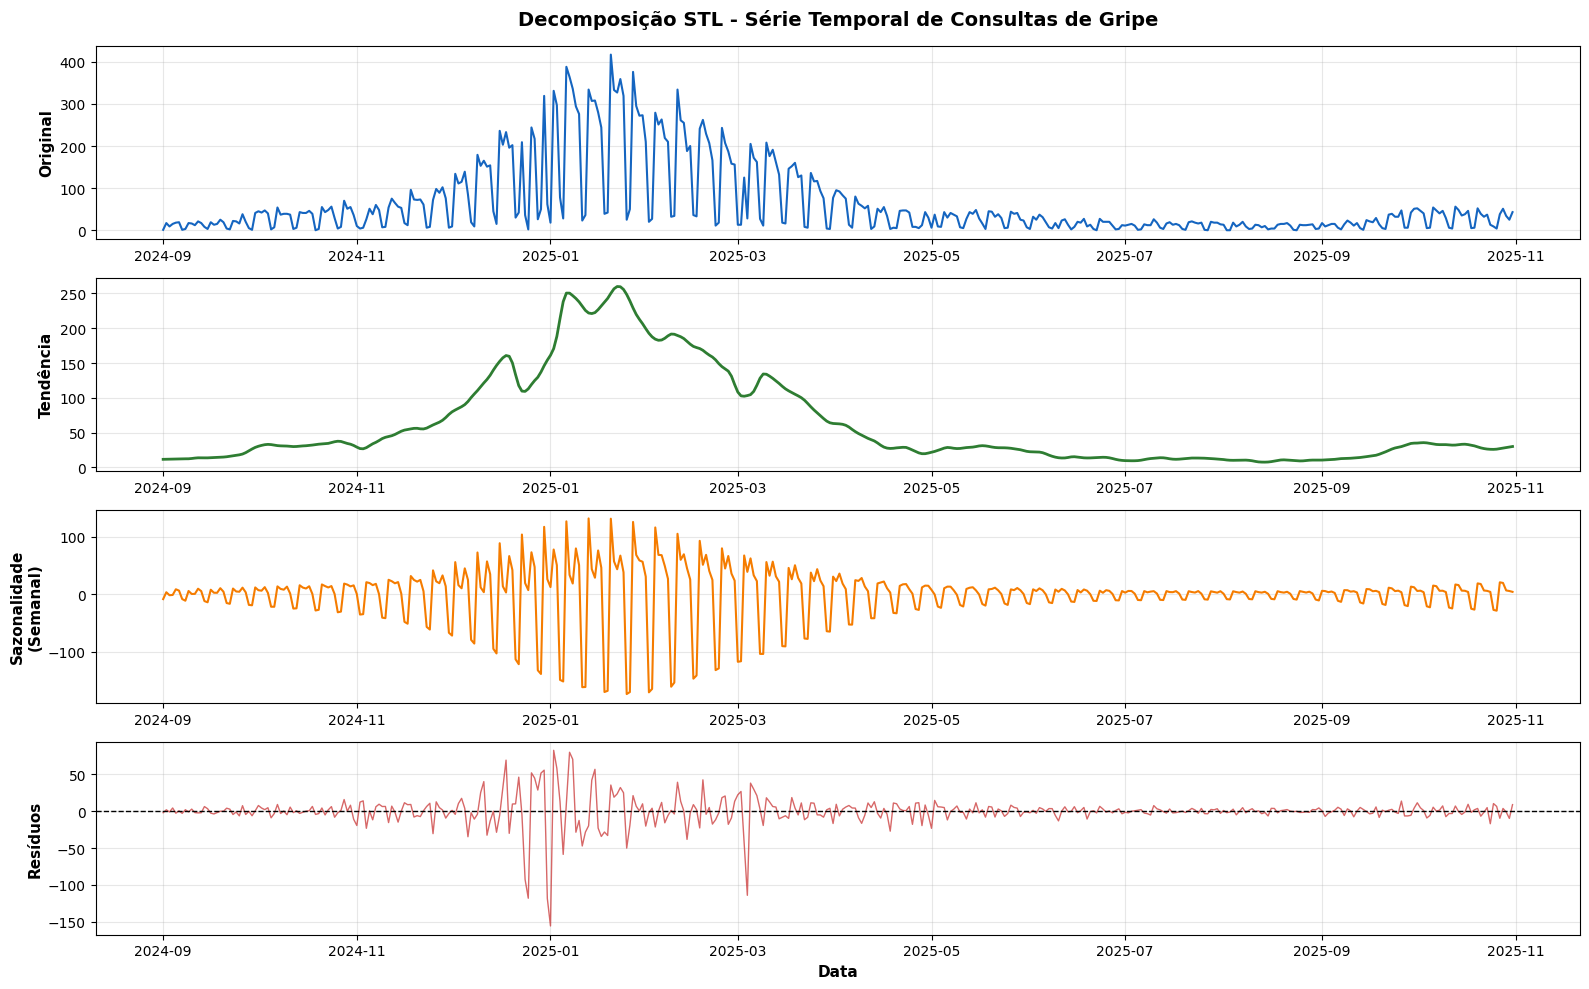

In [20]:
from statsmodels.tsa.seasonal import STL

stl = STL(df_decomp['y'], period=7, seasonal=13)
result = stl.fit()

# Visualização melhorada da decomposição
fig, axes = plt.subplots(4, 1, figsize=(16, 10))

# Série Original
axes[0].plot(df_decomp['ds'], df_decomp['y'], color='#1565C0', linewidth=1.5)
axes[0].set_ylabel('Original', fontsize=11, fontweight='bold')
axes[0].set_title('Decomposição STL - Série Temporal de Consultas de Gripe', 
                  fontsize=14, fontweight='bold', pad=15)
axes[0].grid(True, alpha=0.3)

# Tendência
axes[1].plot(df_decomp['ds'], result.trend, color='#2E7D32', linewidth=2)
axes[1].set_ylabel('Tendência', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Sazonalidade
axes[2].plot(df_decomp['ds'], result.seasonal, color='#F57C00', linewidth=1.5)
axes[2].set_ylabel('Sazonalidade\n(Semanal)', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Resíduos
axes[3].plot(df_decomp['ds'], result.resid, color='#C62828', linewidth=1, alpha=0.7)
axes[3].set_ylabel('Resíduos', fontsize=11, fontweight='bold')
axes[3].set_xlabel('Data', fontsize=11, fontweight='bold')
axes[3].grid(True, alpha=0.3)
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=1)

for ax in axes:
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

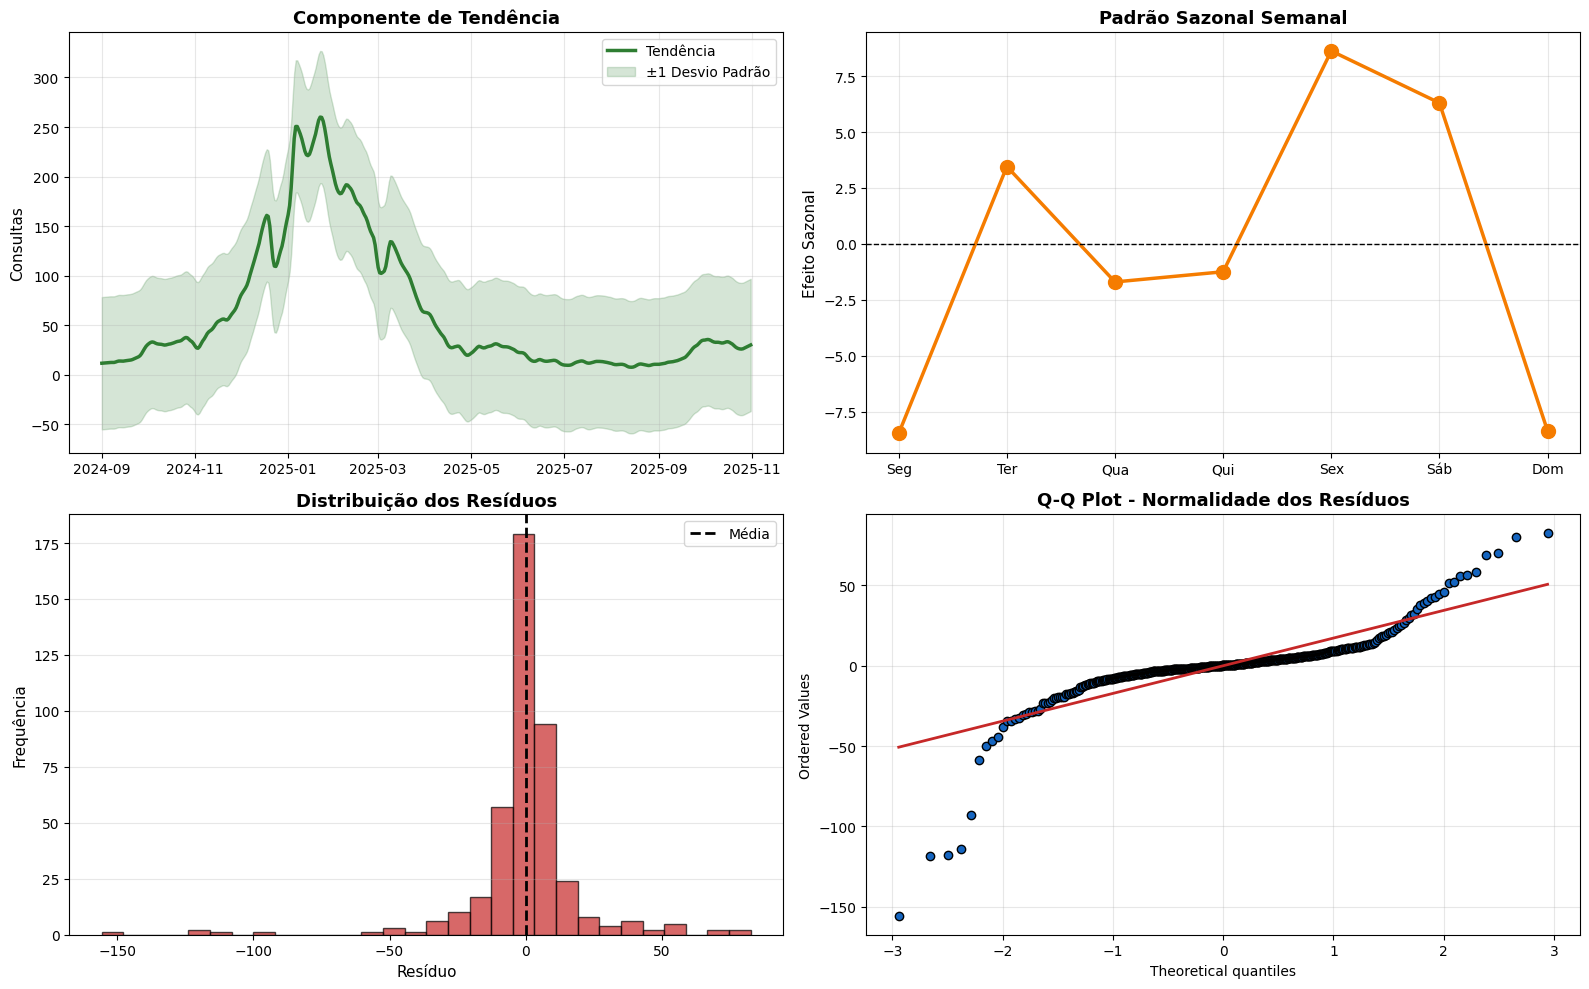


ANÁLISE DOS RESÍDUOS
Média: -0.0044
Desvio Padrão: 20.3730
Mínimo: -155.60
Máximo: 82.56

 Síntese da decomposição:
A decomposição STL revela padrão sazonal semanal bem definido e tendência de crescimento
no período analisado. Os resíduos apresentam comportamento aproximadamente aleatório.


In [21]:
# Análise detalhada dos componentes
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Tendência com banda de confiança
axes[0, 0].plot(df_decomp['ds'], result.trend, color='#2E7D32', linewidth=2.5, label='Tendência')
axes[0, 0].fill_between(df_decomp['ds'], 
                         result.trend - result.trend.std(), 
                         result.trend + result.trend.std(),
                         alpha=0.2, color='#2E7D32', label='±1 Desvio Padrão')
axes[0, 0].set_title("Componente de Tendência", fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("Consultas", fontsize=11)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(labelsize=10)

# 2. Padrão sazonal semanal
seasonal_pattern = result.seasonal[:7]
axes[0, 1].plot(range(7), seasonal_pattern, marker='o', markersize=10, 
                linewidth=2.5, color='#F57C00')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'], fontsize=10)
axes[0, 1].set_title("Padrão Sazonal Semanal", fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel("Efeito Sazonal", fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0, 1].tick_params(labelsize=10)

# 3. Distribuição dos resíduos
axes[1, 0].hist(result.resid.dropna(), bins=30, color='#C62828', 
                edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=2, label='Média')
axes[1, 0].set_title("Distribuição dos Resíduos", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Resíduo", fontsize=11)
axes[1, 0].set_ylabel("Frequência", fontsize=11)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(labelsize=10)

# 4. Q-Q Plot dos resíduos
from scipy import stats
stats.probplot(result.resid.dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot - Normalidade dos Resíduos", fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(labelsize=10)
axes[1, 1].get_lines()[0].set_markerfacecolor('#1565C0')
axes[1, 1].get_lines()[0].set_markeredgecolor('black')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[1].set_color('#C62828')
axes[1, 1].get_lines()[1].set_linewidth(2)

plt.tight_layout()
plt.show()

# Estatísticas dos resíduos
print("\n" + "="*60)
print("ANÁLISE DOS RESÍDUOS")
print("="*60)
print(f"Média: {result.resid.mean():.4f}")
print(f"Desvio Padrão: {result.resid.std():.4f}")
print(f"Mínimo: {result.resid.min():.2f}")
print(f"Máximo: {result.resid.max():.2f}")
print("="*60)

print("\n Síntese da decomposição:")
print("A decomposição STL revela padrão sazonal semanal bem definido e tendência de crescimento")
print("no período analisado. Os resíduos apresentam comportamento aproximadamente aleatório.")

## 4 Determinação do melhor método de previsão

### 4.1 Estratégia experimental

**Horizonte:** h = 7 dias | **Latência:** t-3 | **Validação:** Cross-validation temporal (janelas crescentes)

In [22]:
# ==============================================================================
# ESTRATÉGIA EXPERIMENTAL E PREPARAÇÃO DOS DADOS
# ==============================================================================

lag_days = 3
h = 7
n_windows = 3

# Define o cutoff dinâmico como a última data do dataset menos 3 dias
data_maxima_real = df_ts['ds'].max()
cutoff_date = data_maxima_real - pd.Timedelta(days=lag_days)

# Filtra o dataframe para conter apenas dados até o t-3
df_forecast = df_ts[df_ts['ds'] <= cutoff_date].copy()

print("="*70)
print("CONFIGURAÇÃO DA ESTRATÉGIA EXPERIMENTAL")
print("="*70)
print(f"Horizonte de previsão: {h} dias")
print(f"Informação disponível até (t-3): {cutoff_date.strftime('%Y-%m-%d')}")
print(f"Período dos dados: {df_forecast['ds'].min().strftime('%Y-%m-%d')} até {df_forecast['ds'].max().strftime('%Y-%m-%d')}")
print(f"Total de observações: {len(df_forecast)}")
print("="*70)

CONFIGURAÇÃO DA ESTRATÉGIA EXPERIMENTAL
Horizonte de previsão: 7 dias
Informação disponível até (t-3): 2025-10-28
Período dos dados: 2016-11-01 até 2025-10-28
Total de observações: 3284


### 4.2 Métodos de previsão considerados

**Biblioteca:** StatsForecast (Nixtla)

#### Modelos sem preditores exógenos:
- **SeasonalNaive**: Baseline sazonal (período = 7 dias)
- **AutoETS**: Suavização exponencial (Error, Trend, Seasonality)
- **AutoARIMA**: Seleção automática ARIMA (p, d, q)

#### Modelos com preditores exógenos:
- **AutoARIMA_exog**: ARIMA com variável `is_weekend` (0=Seg-Sex, 1=Sáb-Dom)

**Avaliação:** Cross-validation temporal | **Métricas:** MAE, RMSE

### 4.3. Preparação dos dados

In [23]:
# ==============================================================================
# PREPARAÇÃO DOS DADOS
# ==============================================================================

# Adicionar variável is_weekend
df_forecast['is_weekend'] = (df_forecast['ds'].dt.dayofweek >= 5).astype(int)

print("="*70)
print("DADOS PREPARADOS")
print("="*70)
print(f"Total: {len(df_forecast)} observações")
print(f"Período: {df_forecast['ds'].min().strftime('%Y-%m-%d')} a {df_forecast['ds'].max().strftime('%Y-%m-%d')}")
print(f"\nVariável exógena: is_weekend (0=Seg-Sex, 1=Sáb-Dom)")
print(f"  Dias úteis: {(df_forecast['is_weekend']==0).sum()}")
print(f"  Fim de semana: {(df_forecast['is_weekend']==1).sum()}")
print("="*70)

DADOS PREPARADOS
Total: 3284 observações
Período: 2016-11-01 a 2025-10-28

Variável exógena: is_weekend (0=Seg-Sex, 1=Sáb-Dom)
  Dias úteis: 2346
  Fim de semana: 938


In [24]:
# ==============================================================================
# DEFINIÇÃO DOS MODELOS
# ==============================================================================

season_length = 7

# Modelos SEM preditores exógenos
models_sem = [
    SeasonalNaive(season_length=season_length, alias='SeasonalNaive'),
    AutoETS(season_length=season_length, alias='AutoETS'),
    AutoARIMA(season_length=season_length, alias='AutoARIMA')
]

# Modelo COM preditores exógenos
models_com = [
    AutoARIMA(season_length=season_length, alias='AutoARIMA_exog')
]

print("="*70)
print("MODELOS DEFINIDOS")
print("="*70)
print("\n1. SEM preditores exógenos:")
for m in models_sem:
    print(f"   - {m.alias}")
print("\n2. COM preditores exógenos:")
for m in models_com:
    print(f"   - {m.alias} (usa is_weekend)")
print("="*70)

MODELOS DEFINIDOS

1. SEM preditores exógenos:
   - SeasonalNaive
   - AutoETS
   - AutoARIMA

2. COM preditores exógenos:
   - AutoARIMA_exog (usa is_weekend)


### 4.4. Avaliação das capacidade preditiva e seleção do melhor método

#### 4.4.1. Modelos SEM Preditores Exógenos

In [ ]:
# ==============================================================================
# FASE 1: TREINO SEM PREDITORES EXÓGENOS
# ==============================================================================

print("\n" + "="*70)
print("FASE 1: CROSS-VALIDATION - MODELOS SEM PREDITORES EXÓGENOS")
print("="*70)

sf_sem = StatsForecast(
    models=models_sem,
    freq='D',
    n_jobs=-1
)

cv_sem = sf_sem.cross_validation(
    df=df_forecast[['ds', 'y', 'unique_id']],
    h=h,
    step_size=1,
    n_windows=n_windows
)

# Calcular métricas
metrics_sem = []
for model_col in [col for col in cv_sem.columns if col not in ['ds', 'cutoff', 'y', 'unique_id']]:
    mae_val = np.nanmean(np.abs(cv_sem['y'] - cv_sem[model_col]))
    rmse_val = np.sqrt(np.nanmean((cv_sem['y'] - cv_sem[model_col])**2))
    metrics_sem.append({
        'Modelo': model_col,
        'MAE': mae_val,
        'RMSE': rmse_val,
        'Tipo': 'SEM exógenos'
    })

summary_sem = pd.DataFrame(metrics_sem)
print("\nMétricas dos modelos SEM preditores exógenos:")
print(summary_sem.to_string(index=False))
print("="*70)


FASE 1: CROSS-VALIDATION - MODELOS SEM PREDITORES EXÓGENOS


#### 4.4.2. Modelos COM Preditores Exógenos

In [ ]:
# ==============================================================================
# FASE 2: TREINO COM PREDITORES EXÓGENOS (is_weekend)
# ==============================================================================

print("\n" + "="*70)
print("FASE 2: CROSS-VALIDATION - MODELO COM PREDITORES EXÓGENOS")
print("="*70)

sf_com = StatsForecast(
    models=models_com,
    freq='D',
    n_jobs=-1
)

# Cross-validation com variável exógena
# O StatsForecast detecta automaticamente a coluna is_weekend no dataframe
cv_com = sf_com.cross_validation(
    df=df_forecast[['ds', 'y', 'unique_id', 'is_weekend']],
    h=h,
    step_size=1,
    n_windows=n_windows
)

# Calcular métricas
metrics_com = []
for model_col in [col for col in cv_com.columns if col not in ['ds', 'cutoff', 'y', 'unique_id']]:
    mae_val = np.nanmean(np.abs(cv_com['y'] - cv_com[model_col]))
    rmse_val = np.sqrt(np.nanmean((cv_com['y'] - cv_com[model_col])**2))
    metrics_com.append({
        'Modelo': model_col,
        'MAE': mae_val,
        'RMSE': rmse_val,
        'Tipo': 'COM exógenos'
    })

summary_com = pd.DataFrame(metrics_com)
print("\nMétricas do modelo COM preditores exógenos:")
print(summary_com.to_string(index=False))
print("="*70)


FASE 2: CROSS-VALIDATION - MODELO COM PREDITORES EXÓGENOS


#### 4.4.3. Comparação de Todos os Modelos

In [ ]:
# ==============================================================================
# COMPARAÇÃO DE TODOS OS MODELOS
# ==============================================================================

# Combinar todas as métricas
all_models = pd.concat([summary_sem, summary_com], ignore_index=True)

# Ordenar por MAE
all_models = all_models.sort_values('MAE').reset_index(drop=True)

print("\n" + "="*70)
print("COMPARAÇÃO DE TODOS OS MODELOS (ordenado por MAE)")
print("="*70)
print(all_models.to_string(index=False))
print("="*70)

# Identificar o melhor modelo
best_model_final = all_models.iloc[0]['Modelo']
best_mae_final = all_models.iloc[0]['MAE']
best_rmse_final = all_models.iloc[0]['RMSE']
uses_exog = all_models.iloc[0]['Tipo'] == 'COM exógenos'

print(f"\n MELHOR MODELO: {best_model_final}")
print(f"   MAE:  {best_mae_final:.2f}")
print(f"   RMSE: {best_rmse_final:.2f}")
print(f"   Tipo: {all_models.iloc[0]['Tipo']}")
print("="*70)


COMPARAÇÃO DE TODOS OS MODELOS (ordenado por MAE)
        Modelo        MAE       RMSE         Tipo
 SeasonalNaive 175.142853 267.258575 SEM exógenos
AutoARIMA_exog 262.478210 333.418518 COM exógenos
       AutoETS 263.926727 327.090332 SEM exógenos
     AutoARIMA 281.870697 350.482513 SEM exógenos

🏆 MELHOR MODELO: SeasonalNaive
   MAE:  175.14
   RMSE: 267.26
   Tipo: SEM exógenos


#### 4.4.4. Visualização Comparativa

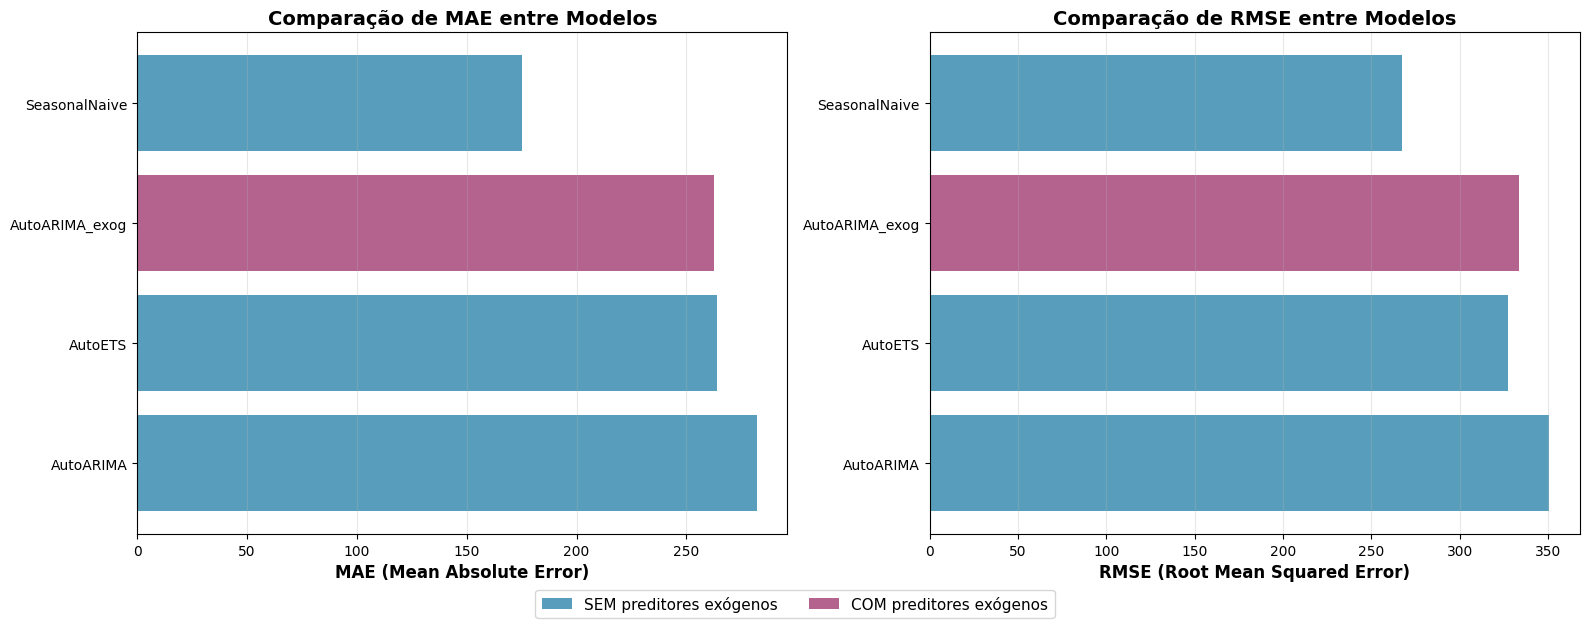


✓ Visualização comparativa concluída


In [ ]:
# ==============================================================================
# VISUALIZAÇÃO COMPARATIVA
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Cores por tipo
colors = ['#2E86AB' if t == 'SEM exógenos' else '#A23B72' for t in all_models['Tipo']]

# Gráfico MAE
ax1.barh(all_models['Modelo'], all_models['MAE'], color=colors, alpha=0.8)
ax1.set_xlabel('MAE (Mean Absolute Error)', fontsize=12, fontweight='bold')
ax1.set_title('Comparação de MAE entre Modelos', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()

# Gráfico RMSE
ax2.barh(all_models['Modelo'], all_models['RMSE'], color=colors, alpha=0.8)
ax2.set_xlabel('RMSE (Root Mean Squared Error)', fontsize=12, fontweight='bold')
ax2.set_title('Comparação de RMSE entre Modelos', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', alpha=0.8, label='SEM preditores exógenos'),
    Patch(facecolor='#A23B72', alpha=0.8, label='COM preditores exógenos')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

print(f"\n✓ Visualização comparativa concluída")

## 5. Previsões objetivo

**Período:** 2025-12-06 a 2025-12-12 | **Data de referência:** 2025-12-03

### 5.1. Melhor modelo

In [ ]:
# ==============================================================================
# TREINO FINAL DO MELHOR MODELO
# ==============================================================================

print("\n" + "="*70)
print(f"TREINO FINAL COM {best_model_final}")
print("="*70)

# Data de referência: 2025-12-03 (último dia com dados disponíveis)
data_referencia = pd.Timestamp('2025-12-03')
print(f"Data de referência: {data_referencia.strftime('%Y-%m-%d')} ({data_referencia.day_name()})")

# Dados até a data de referência
df_ate_referencia = df_forecast[df_forecast['ds'] <= data_referencia].copy()
print(f"Dados até referência: {len(df_ate_referencia)} observações")

# Parâmetro de sazonalidade (7 dias por semana)
season_length = 7

# Criar StatsForecast com o melhor modelo
if uses_exog:
    # Modelo COM preditores exógenos
    model_obj = models_com[0]  # AutoARIMA_exog
    sf_final = StatsForecast(models=[model_obj], freq='D', n_jobs=-1)
    
    # Treinar com is_weekend
    sf_final.fit(df=df_ate_referencia[['ds', 'y', 'unique_id', 'is_weekend']])
else:
    # Modelo SEM preditores exógenos
    if 'SeasonalNaive' in best_model_final:
        model_obj = SeasonalNaive(season_length=season_length, alias='SeasonalNaive')
    elif 'AutoETS' in best_model_final:
        model_obj = AutoETS(season_length=season_length, alias='AutoETS')
    elif 'AutoARIMA' in best_model_final:
        model_obj = AutoARIMA(season_length=season_length, alias='AutoARIMA')
    
    sf_final = StatsForecast(models=[model_obj], freq='D', n_jobs=-1)
    
    # Treinar sem preditores exógenos
    sf_final.fit(df=df_ate_referencia[['ds', 'y', 'unique_id']])

print("\n✓ Modelo treinado com sucesso")
print("="*70)


TREINO FINAL COM SeasonalNaive
Data de referência: 2025-12-03 (Wednesday)
Dados até referência: 459 observações

✓ Modelo treinado com sucesso


### 5.2. Análise dos resíduos

ESTATÍSTICAS DOS RESÍDUOS
Média: 2.27
Desvio padrão: 39.26
Mínimo: -231.00
Máximo: 318.00
Mediana: 1.00
Q1 (25%): -6.00
Q3 (75%): 9.00


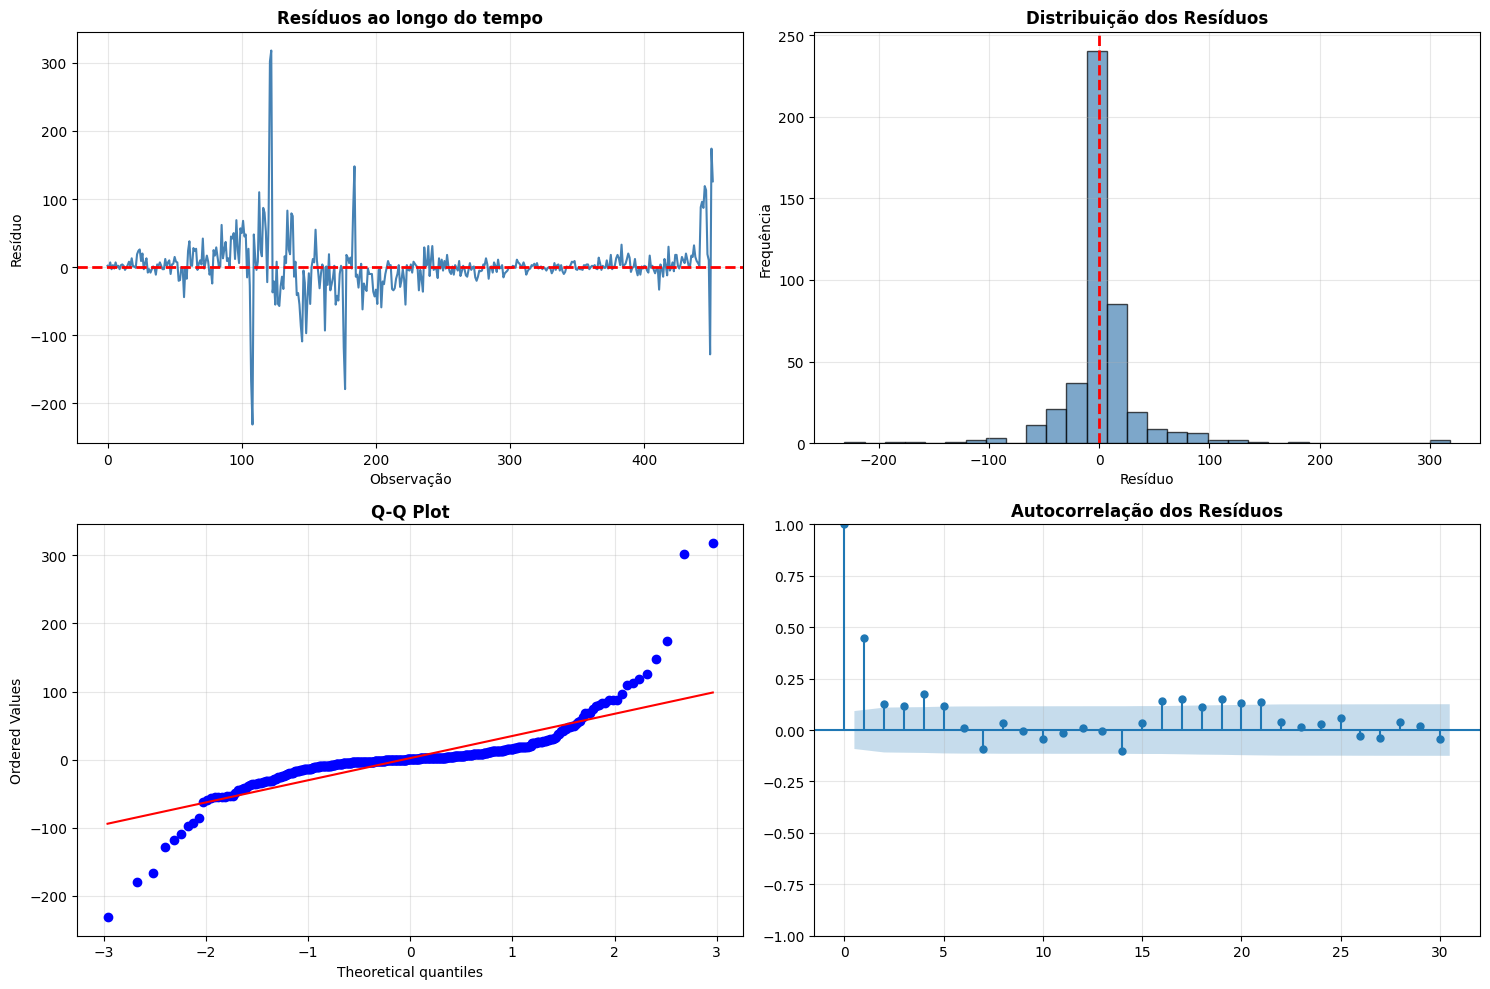


✓ Análise de resíduos concluída


In [ ]:
# ==============================================================================
# ANÁLISE DOS RESÍDUOS DO MODELO FINAL
# ==============================================================================

# Para SeasonalNaive, o resíduo é simplesmente a diferença entre o valor observado
# e o valor da mesma semana anterior (season_length=7)
season_length = 7
residuals = df_ate_referencia['y'].values[season_length:] - df_ate_referencia['y'].values[:-season_length]

print("="*70)
print("ESTATÍSTICAS DOS RESÍDUOS")
print("="*70)
print(f"Média: {np.mean(residuals):.2f}")
print(f"Desvio padrão: {np.std(residuals):.2f}")
print(f"Mínimo: {np.min(residuals):.2f}")
print(f"Máximo: {np.max(residuals):.2f}")
print(f"Mediana: {np.median(residuals):.2f}")
print(f"Q1 (25%): {np.percentile(residuals, 25):.2f}")
print(f"Q3 (75%): {np.percentile(residuals, 75):.2f}")
print("="*70)

# Visualizações
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Resíduos ao longo do tempo
axes[0, 0].plot(residuals, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_title('Resíduos ao longo do tempo', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Observação')
axes[0, 0].set_ylabel('Resíduo')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma
axes[0, 1].hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_title('Distribuição dos Resíduos', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Resíduo')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. ACF dos resíduos
from statsmodels.graphics.tsaplots import plot_acf
# Usar no máximo len(residuals)//2 lags
max_lags = min(len(residuals)//2, 30)
plot_acf(residuals, lags=max_lags, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelação dos Resíduos', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Análise de resíduos concluída")

### 5.3. Previsões objetivo (com intervalos de previsão)

PREVISÕES PARA O PERÍODO DE 2025-12-06 A 2025-12-12

Modelo: SeasonalNaive
Período: 2025-12-06 a 2025-12-10
Número de dias: 5

      Data Dia da semana  Previsão  IC 80% inferior  IC 80% superior  IC 95% inferior  IC 95% superior
2025-12-06      Saturday      29.0       -21.400000        79.400002       -48.099998       106.099998
2025-12-07        Sunday      20.0       -30.400000        70.400002       -57.099998        97.099998
2025-12-08        Monday      37.0       -13.400000        87.400002       -40.099998       114.099998
2025-12-09       Tuesday     340.0       289.600006       390.399994       262.899994       417.100006
2025-12-10     Wednesday     303.0       252.600006       353.399994       225.899994       380.100006


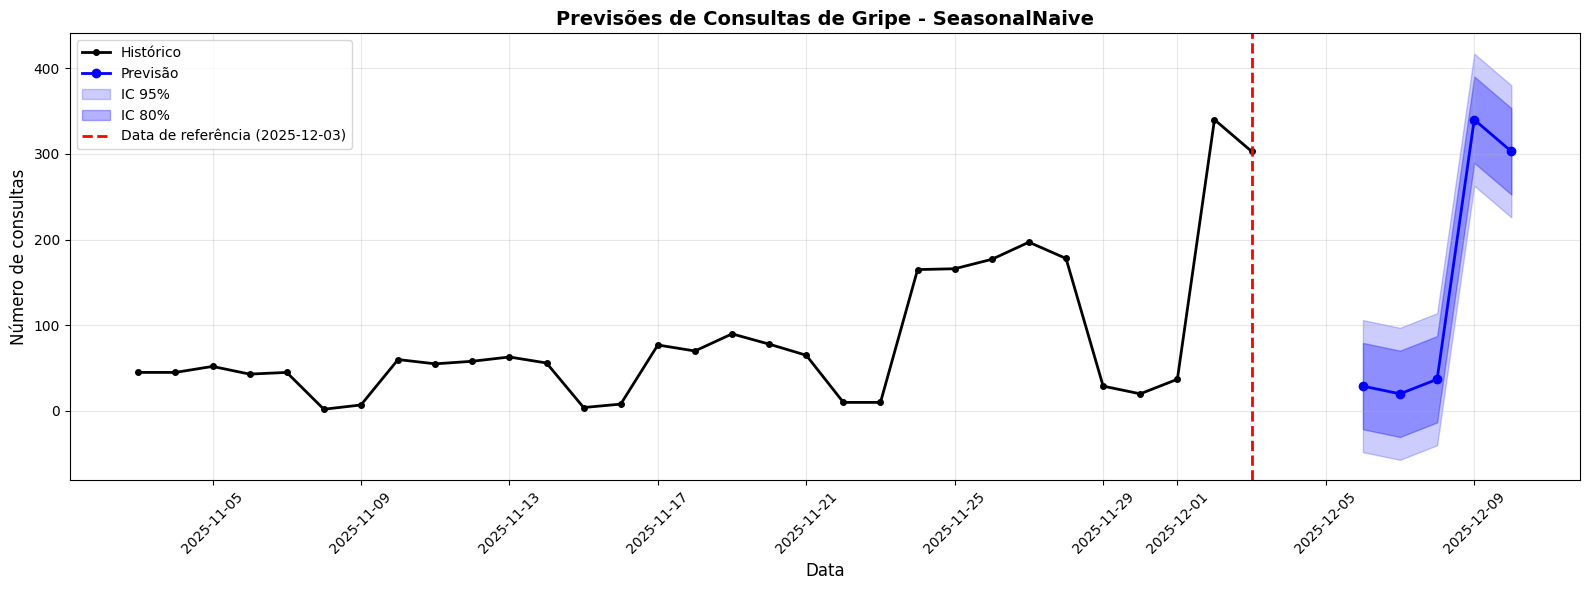


✓ Previsões finais concluídas


In [ ]:
# ==============================================================================
# PREVISÕES OBJETIVO COM INTERVALOS DE CONFIANÇA
# ==============================================================================

# Fazer previsões com intervalos de confiança de 80% e 95%
forecast_final = sf_final.forecast(
    df=df_ate_referencia[['ds', 'y', 'unique_id']],
    h=7,
    level=[80, 95]
)

# Filtrar apenas as datas objetivo
forecast_objetivo = forecast_final[
    (forecast_final['ds'] >= '2025-12-06') & 
    (forecast_final['ds'] <= '2025-12-12')
].copy()

print("="*70)
print("PREVISÕES PARA O PERÍODO DE 2025-12-06 A 2025-12-12")
print("="*70)
print(f"\nModelo: {best_model}")
print(f"Período: {forecast_objetivo['ds'].min().date()} a {forecast_objetivo['ds'].max().date()}")
print(f"Número de dias: {len(forecast_objetivo)}\n")

# Criar tabela formatada
forecast_table = pd.DataFrame({
    'Data': forecast_objetivo['ds'].dt.date,
    'Dia da semana': forecast_objetivo['ds'].dt.day_name(),
    'Previsão': forecast_objetivo['SeasonalNaive'].round(1),
    'IC 80% inferior': forecast_objetivo['SeasonalNaive-lo-80'].round(1),
    'IC 80% superior': forecast_objetivo['SeasonalNaive-hi-80'].round(1),
    'IC 95% inferior': forecast_objetivo['SeasonalNaive-lo-95'].round(1),
    'IC 95% superior': forecast_objetivo['SeasonalNaive-hi-95'].round(1)
})

print(forecast_table.to_string(index=False))
print("="*70)

# Visualização
fig, ax = plt.subplots(figsize=(16, 6))

# Dados históricos (últimos 30 dias)
df_historico_viz = df_ate_referencia[df_ate_referencia['ds'] >= (data_referencia - pd.Timedelta(days=30))]
ax.plot(df_historico_viz['ds'], df_historico_viz['y'], 
        label='Histórico', color='black', linewidth=2, marker='o', markersize=4)

# Previsões
ax.plot(forecast_objetivo['ds'], forecast_objetivo['SeasonalNaive'], 
        label='Previsão', color='blue', linewidth=2, marker='o', markersize=6)

# Intervalos de confiança
ax.fill_between(forecast_objetivo['ds'], 
                forecast_objetivo['SeasonalNaive-lo-95'], 
                forecast_objetivo['SeasonalNaive-hi-95'],
                alpha=0.2, color='blue', label='IC 95%')
ax.fill_between(forecast_objetivo['ds'], 
                forecast_objetivo['SeasonalNaive-lo-80'], 
                forecast_objetivo['SeasonalNaive-hi-80'],
                alpha=0.3, color='blue', label='IC 80%')

# Linha vertical na data de referência
ax.axvline(x=data_referencia, color='red', linestyle='--', linewidth=2, 
           label=f'Data de referência ({data_referencia.date()})')

ax.set_title(f'Previsões de Consultas de Gripe - {best_model}', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Número de consultas', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✓ Previsões finais concluídas")